In [34]:
import os
import glob
import random
import re
import math

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

import spacy
import umap

from sentence_transformers import SentenceTransformer

from sklearn.cluster import (
    DBSCAN,
    KMeans,
    BisectingKMeans,
    SpectralClustering
)

from sklearn.decomposition import (
    NMF,
    TruncatedSVD
)

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.manifold import TSNE

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.preprocessing import (
    normalize,
    Normalizer
)

from sklearn_extra.cluster import KMedoids

# Diccionario para almacenar los resultados y compararlos al final
resultados_globales = {}

Cargando datos de forma no supervisada...
Vectorizando texto...
Reduciendo dimensiones...
Ejecutando Spectral Clustering...

--- MÉTRICAS DE CALIDAD (NO SUPERVISADAS) ---
1. Coeficiente de Silueta: 0.5656
   (Rango de -1 a 1. Valores más cercanos a 1 indican mejor separación y cohesión).

2. Índice de Davies-Bouldin: 1.0820
   (Valores más cercanos a 0 indican clusters mejor separados y más compactos).

--- RESULTADOS SPECTRAL CLUSTERING ---

  CLUSTER 0 (CYAN) — Total: 960 reseñas

  [ID 13] As much as the movie was good, i have nothing more to say about it than what was said already. all i wanted is to point the fact that the movie isnt from Sweden but from Denemark. Maybe I wrong and in that case i'll be happy to know my mistakes so take the and notify me....
----------------------------------------

  [ID 22] Gotta start with Ed Furlong on this one. You gotta. God bless this kid. $5 bucks says the character he plays in this film is what he's really like in real life. He has a one-l

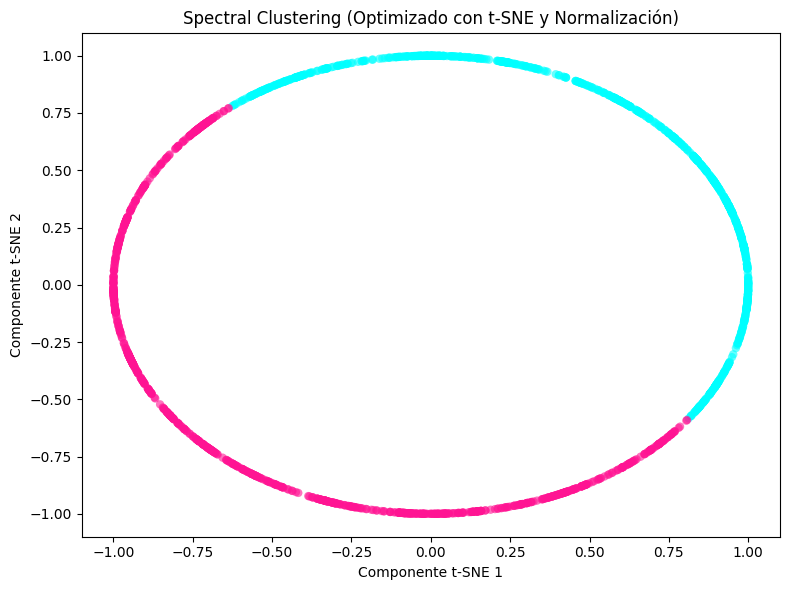

In [35]:
#SPECTRAL

# --- PASO 1: Cargar los datos (100% Ciego) ---
from sklearn.metrics import silhouette_samples


def load_imdb_data(directory, sample_size=1000):
    """
    Recorre las carpetas de reseñas y extrae el texto puro.
    Al ser no supervisado, no guardamos si provienen de la carpeta 'pos' o 'neg'.
    """
    texts = []
    # Recorremos ambas carpetas solo para recolectar los archivos
    for category in ['pos', 'neg']:
        path = os.path.join(directory, 'train', category)

        # Limitamos la lectura al sample_size (1000 por carpeta)
        files = os.listdir(path)[:sample_size]

        # Abrimos cada archivo en modo lectura con codificación UTF-8
        for fname in files:
            with open(os.path.join(path, fname), 'r', encoding='utf-8') as f:
                texts.append(f.read())

    # Retornamos una única lista mezclada con todos los textos
    return texts


print("Cargando datos de forma no supervisada...")
reviews = load_imdb_data('/home/pedro/Documentos/ESCOM/5to Semestre/Machine/aclImdb', sample_size=1000)

# --- PASO 2: Vectorización (Con Filtros Avanzados) ---
print("Vectorizando texto...")

# 1. Creamos una "lista negra" personalizada con palabras hiper-frecuentes en el cine
# que actúan como "pegamento" indeseado entre reseñas positivas y negativas.
palabras_basura_cine = ['movie', 'film', 'character', 'characters', 'story',
                        'time', 'watch', 'acting', 'director', 'scene', 'scenes',
                        'minutes', 'plot', 'make', 'just', 'like', 'really']

# Unimos las stop words clásicas del inglés con nuestra lista negra
mis_stopwords = list(ENGLISH_STOP_WORDS) + palabras_basura_cine

# 2. Configuramos el vectorizador matemático
vectorizer = TfidfVectorizer(
    stop_words=mis_stopwords,  # Usamos nuestra lista combinada
    max_features=2000,  # Nos quedamos con el top 2000 de palabras más relevantes
    max_df=0.5,  # Ignora palabras que aparezcan en más del 50% de los documentos
    min_df=5,  # Ignora errores ortográficos que aparezcan en menos de 5 reseñas
    sublinear_tf=True  # Suaviza matemáticamente (logaritmo) a las personas que repiten mucho una palabra
)

# Transformamos los textos en nuestra matriz matemática X
X = vectorizer.fit_transform(reviews)

# --- PASO 3: Reducción de Dimensionalidad (SVD + t-SNE + Normalización) ---
print("Reduciendo dimensiones...")

# 1. Primera compresión: SVD rápido para bajar de 2000 a 50 dimensiones y aligerar la memoria
svd = TruncatedSVD(n_components=50, random_state=42)
X_temp = svd.fit_transform(X)

# 2. Segunda compresión ("La opción nuclear"): t-SNE desgarra el espacio de 50D a 2D
# forzando a los puntos similares a formar islas muy apretadas.
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_reduced = tsne.fit_transform(X_temp)

# 3. Ecualización geométrica: Empuja todos los puntos hacia el borde de un círculo (magnitud=1).
# Esto evita que el algoritmo se confunda entre reseñas cortas y largas.
X_reduced = Normalizer().fit_transform(X_reduced)

# --- PASO 4: Ejecutar Spectral Clustering ---
print("Ejecutando Spectral Clustering...")

# Configuramos el algoritmo de teoría de grafos
spectral = SpectralClustering(
    n_clusters=2,  # Queremos descubrir 2 temáticas subyacentes
    affinity='nearest_neighbors',  # Conecta los puntos más cercanos para armar su "red"
    random_state=42,  # Semilla de reproducibilidad
    n_neighbors=100,  # Forzamos conexiones globales altas para evitar aislar anomalías (outliers)
    assign_labels='kmeans'  # Fuerza un corte equilibrado de los grupos al final
)

# El modelo agrupa la red de textos y devuelve un arreglo de ceros y unos
clusters = spectral.fit_predict(X_reduced)

# --- PASO 5: Evaluación de Métricas de Calidad ---
print("\n--- MÉTRICAS DE CALIDAD (NO SUPERVISADAS) ---")

# 1. Silueta (Distancia Coseno)
# Crucial: Usamos metric='cosine' porque en textos normalizados en forma de anillo,
# se deben medir los ángulos, no las líneas rectas.
silueta = silhouette_score(X_reduced, clusters, metric='cosine')
print(f"1. Coeficiente de Silueta: {silueta:.4f}")
print("   (Rango de -1 a 1. Valores más cercanos a 1 indican mejor separación y cohesión).")

# 2. Índice de Davies-Bouldin
db_index = davies_bouldin_score(X_reduced, clusters)
print(f"\n2. Índice de Davies-Bouldin: {db_index:.4f}")
print("   (Valores más cercanos a 0 indican clusters mejor separados y más compactos).")

# --- PASO 6: Mostrar Resultados en Ventana ---
print("\n--- RESULTADOS SPECTRAL CLUSTERING ---")
for cluster_id in [0, 1]:
    nombre_color = "CYAN" if cluster_id == 0 else "MAGENTA"
    total = clusters.tolist().count(cluster_id)
    print(f"\n{'='*60}")
    print(f"  CLUSTER {cluster_id} ({nombre_color}) — Total: {total} reseñas")
    print(f"{'='*60}")
    indices = [i for i, e in enumerate(clusters) if e == cluster_id]
    for i in indices[:3]:   # Muestra las primeras 3 reseñas de cada cluster
        print(f"\n  [ID {i}] {reviews[i][:300]}...")
        print("-" * 40)
    if total > 3:
        print(f"  ... y {total - 3} reseñas más en este cluster.")

print("\n¡Proceso completado!")

# --- PASO 7: Visualización de los Clusters en 2D ---
print("Generando gráfico de dispersión...")

# Preparamos el lienzo
plt.figure(figsize=(8, 6))

# Definimos nuestra paleta de colores personalizada
mis_colores = ['#00FFFF', '#FF1493']  # Cyan (Cluster 0) y Magenta Intenso (Cluster 1)

# Asignamos a cada punto su color exacto basado en el resultado del clustering
lista_colores_puntos = [mis_colores[c] for c in clusters]

# Dibujamos el gráfico de dispersión (Scatter plot) usando las coordenadas t-SNE
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=lista_colores_puntos, alpha=0.6, edgecolors='none')

# Etiquetas del gráfico
plt.title('Spectral Clustering (Optimizado con t-SNE y Normalización)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')

# Ajuste automático de márgenes
plt.tight_layout()

# Desplegamos la ventana visual
plt.show()

resultados_globales["Spectral"] = {"silhouette": silueta}

1. Cargando datos...
   Extrayendo solo adjetivos y adverbios (esto tomará un momento)...

2. Generando Embeddings de las emociones...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

   Comprimiendo el espacio con UMAP para forzar la separación...


/home/pedro/Documentos/ESCOM/5to Semestre/Machine/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



3. Explorando el número ideal de clusters...
   Probando con 2 grupos -> Silueta: 0.4144
   Probando con 3 grupos -> Silueta: 0.4126
   Probando con 4 grupos -> Silueta: 0.3856
   Probando con 5 grupos -> Silueta: 0.3783

4. Ejecutando K-Medoids final con 2 clusters...

--- MÉTRICAS DE CALIDAD ---
1. Coeficiente de Silueta Final: 0.4144
2. Índice de Davies-Bouldin Final: 1.3426

--- DESCUBRIENDO LOS GRUPOS ---

[ GRUPO 0 ] - Representante:
Had a bad day? Dog bit the mailman? Car wouldn't start? People got on your nerves? Then refresh yourself with a delightful experience.<br /><br />Two women decide to pool their resources in answer to an ad for a month's rental of a villa in Italy. Due to financial circumstances, two other women join...

[ GRUPO 1 ] - Representante:
I picked up this movie for $5 dollars at a discount book store, Adam Sandler is a awesome actor and i figured it would be a good movie, well, it wasn't. There was absolutely no story line at all, bad jokes, and the other 

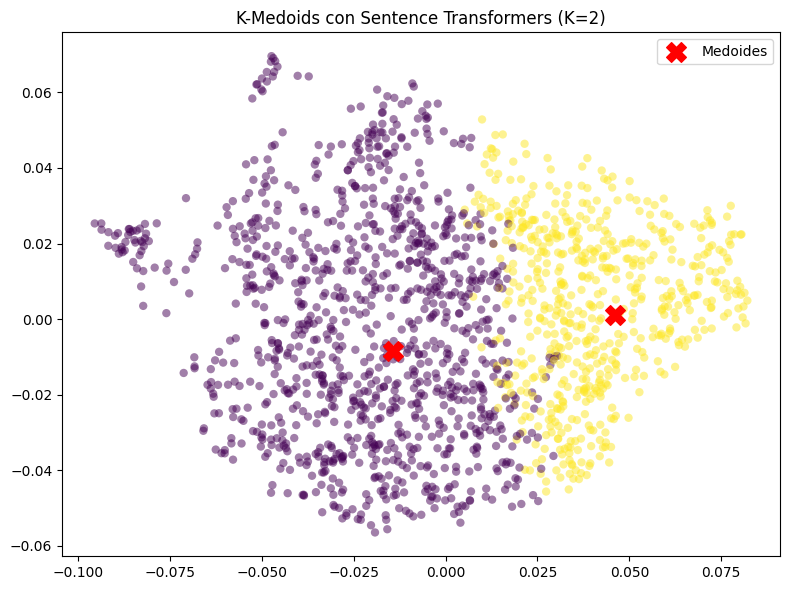


--- RESULTADOS K-MEDOIDS ---

  CLUSTER 0 — Total: 1090 reseñas

  [Reseña #1] Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik...
----------------------------------------

  [Reseña #2] Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking the Waves have gotten more acc...
----------------------------------------

  [Reseña #3] Lars Von Trier is never backward in trying out new techniques. Some of them are very original while others are best forgotten.<br /><br />He depicts postwar Germany as a nightmarish train journey. Wit

In [36]:
#KMEDOIDS

# ==========================================
# DEFINICIÓN DE FUNCIONES
# ==========================================
def load_imdb_data(directory, sample_size=1000):
    texts = []
    for category in ['pos', 'neg']:
        path = os.path.join(directory, 'train', category)
        try:
            files = os.listdir(path)[:sample_size]
            for fname in files:
                with open(os.path.join(path, fname), 'r', encoding='utf-8') as f:
                    texts.append(f.read())
        except FileNotFoundError:
            print(f"Advertencia: No se encontró la ruta {path}.")
    return texts


def extraer_emociones(textos):
    print("   Extrayendo solo adjetivos y adverbios (esto tomará un momento)...")
    # Desactivamos 'ner' y 'parser' para que sea rápido, pero necesitamos el 'tagger'
    nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

    textos_emocionales = []
    for doc in nlp.pipe(textos, batch_size=50):
        # Magia pura: Nos quedamos SOLO con palabras que describen emociones/calidad
        emociones = " ".join([token.lemma_.lower() for token in doc if token.pos_ in ['ADJ', 'ADV']])
        textos_emocionales.append(emociones)
    return textos_emocionales


# ==========================================
# EJECUCIÓN DEL FLUJO PRINCIPAL
# ==========================================

# --- PASO 1: Cargar y limpiar ---
print("1. Cargando datos...")
reviews_originales = load_imdb_data('/home/pedro/Documentos/ESCOM/5to Semestre/Machine/aclImdb', sample_size=1000)

# Filtramos por longitud para quitar outliers
reviews = [r for r in reviews_originales if 50 < len(r.split()) < 400]

# ¡AQUÍ APLICAMOS EL FILTRO EMOCIONAL!
reviews_filtradas = extraer_emociones(reviews)

# --- PASO 2: Embeddings y UMAP ---
print("\n2. Generando Embeddings de las emociones...")
model = SentenceTransformer('all-MiniLM-L6-v2')
X_embeddings = model.encode(reviews_filtradas, show_progress_bar=True)

print("   Comprimiendo el espacio con UMAP para forzar la separación...")
# Reducimos a 5 dimensiones súper densas
reductor = umap.UMAP(n_components=5, metric='cosine', random_state=42)
X_umap = reductor.fit_transform(X_embeddings)

# Normalizamos
X_reduced = Normalizer(copy=False).fit_transform(X_umap)

# --- PASO 3: Explorar Clusters ---
print("\n3. Explorando el número ideal de clusters...")
for k in range(2, 6):
    kmedoids_prueba = KMedoids(n_clusters=k, metric='cosine', method='pam', init='heuristic', random_state=42)
    clusters_prueba = kmedoids_prueba.fit_predict(X_reduced)
    silueta_prueba = silhouette_score(X_reduced, clusters_prueba, metric='cosine')
    print(f"   Probando con {k} grupos -> Silueta: {silueta_prueba:.4f}")

# --- PASO 4: Modelo Final ---
MEJOR_K = 2 # Puedes ajustar esto según lo que imprima el ciclo de arriba
print(f"\n4. Ejecutando K-Medoids final con {MEJOR_K} clusters...")
kmedoids = KMedoids(n_clusters=MEJOR_K, metric='cosine', method='pam', init='heuristic', random_state=42)
clusters = kmedoids.fit_predict(X_reduced)

# --- MÉTRICAS DE CALIDAD ---
print("\n--- MÉTRICAS DE CALIDAD ---")
silueta = silhouette_score(X_reduced, clusters, metric='cosine')
print(f"1. Coeficiente de Silueta Final: {silueta:.4f}")

db_index = davies_bouldin_score(X_reduced, clusters)
print(f"2. Índice de Davies-Bouldin Final: {db_index:.4f}")

# --- VISUALIZACIÓN ---
# Como ahora tenemos 384 dimensiones, usamos PCA rápido solo para poder dibujarlo en 2D.
# ¡Ojo! El modelo NO usó esto, es solo para el dibujo.
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
pca = PCA(n_components=2)
X_dibujo = pca.fit_transform(X_reduced)
medoides_dibujo = X_dibujo[kmedoids.medoid_indices_]

print("\n--- DESCUBRIENDO LOS GRUPOS ---")
for i, medoid_idx in enumerate(kmedoids.medoid_indices_):
    print(f"\n[ GRUPO {i} ] - Representante:")
    # Imprimimos los primeros 300 caracteres de la reseña original
    print(f"{reviews_originales[medoid_idx][:300]}...")

print("\n5. Generando gráfico de dispersión...")
plt.figure(figsize=(8, 6))
plt.scatter(X_dibujo[:, 0], X_dibujo[:, 1], c=clusters, cmap='viridis', alpha=0.5, edgecolors='none')
plt.scatter(medoides_dibujo[:, 0], medoides_dibujo[:, 1], c='red', marker='X', s=200, label='Medoides')
plt.title(f'K-Medoids con Sentence Transformers (K={MEJOR_K})')
plt.legend()
plt.tight_layout()
plt.show()

# Resultados en Ventana

print("\n--- RESULTADOS K-MEDOIDS ---")
clusters_dict = {}
for i, label in enumerate(clusters):
    clusters_dict.setdefault(label, []).append(reviews[i])

for label, textos in sorted(clusters_dict.items()):
    print(f"\n{'='*60}")
    print(f"  CLUSTER {label} — Total: {len(textos)} reseñas")
    print(f"{'='*60}")
    for idx, reseña in enumerate(textos[:3]):
        print(f"\n  [Reseña #{idx+1}] {reseña[:300]}...")
        print("-" * 40)
    if len(textos) > 3:
        print(f"  ... y {len(textos) - 3} reseñas más.")

resultados_globales["K-Medoids"] = {"silhouette": silueta}

In [37]:
#DBSCAN

# CARGA DE DATOS
# Esta funcion implementa la extraccion de datos crudos mediante el recorrido del sistema de archivos.
# Especificamente busca en las subcarpetas "pos" y "neg" dentro de la estructura estandar del dataset IMDB
# para etiquetar implicitamente o simplemente agrupar las resenas de texto.
def load_imdb_data(base_path):
    texts = []
    
    # Se recorren las dos clases fundamentales: positivas y negativas para asegurar una carga balanceada
    for label in ['pos', 'neg']:
        # Se construye el patron de busqueda utilizando glob para localizar todos los archivos .txt 
        # en el directorio de entrenamiento (train) permitiendo la recursividad en las subcarpetas.
        pattern = os.path.join(base_path, '**', 'train', label, '*.txt')
        files = glob.glob(pattern, recursive=True)

        # Se realiza la apertura de archivos en UTF-8 para evitar errores de caracteres especiales.
        # El contenido de cada resena se añade a una lista que servira como corpus de entrada.
        for file_path in files:
            with open(file_path, encoding='utf-8') as f:
                texts.append(f.read())  # Captura el flujo de texto completo de la resena
    
    return texts

path = r'/home/pedro/Documentos/ESCOM/5to Semestre/Machine/aclImdb'

# Invocacion de la funcion de carga para obtener el corpus de texto en memoria
reviews = load_imdb_data(path)

# Transformacion de la lista de strings a un objeto DataFrame de Pandas para aprovechar las
# capacidades de manipulacion matricial filtrado y visualizacion tabular de datos.
df = pd.DataFrame(reviews, columns=['review'])

# REDUCCION DEL DATASET (SUB-MUESTREO)
# Dado que el procesamiento de lenguaje natural (NLP) genera matrices esparzas muy grandes 
# se selecciona una muestra aleatoria de 5000 registros para optimizar el tiempo de ejecucion 
# y el consumo de memoria RAM durante el entrenamiento de los modelos de clustering.
df = df.sample(5000, random_state=42).reset_index(drop=True)


# REPRESENTACION VECTORIAL TF-IDF (Term Frequency - Inverse Document Frequency)
# Se transforma el texto no estructurado en una representacion numerica ponderada.
# TF-IDF resalta las palabras que son frecuentes en un documento pero raras en el corpus general
# ayudando a identificar terminos con alto valor semantico y discriminativo.
vectorizer = TfidfVectorizer(
    max_features=3000,      # Limita el vocabulario a las 3000 palabras con mayor frecuencia para reducir ruido
    stop_words='english',   # Filtra conectores y articulos (the and is) que no aportan significado semantico
    ngram_range=(1,2)       # Incluye tanto palabras sueltas como pares de palabras adyacentes para captar contexto
)

# Ajuste del vocabulario y transformacion del corpus en una matriz de terminos-documentos (Sparse Matrix)
X = vectorizer.fit_transform(df['review'])

# Normalizacion L2 de los vectores resultantes para asegurar que la longitud de las resenas 
# no afecte el calculo de distancias situando todos los puntos en una hiperesfera de radio 1.
X = normalize(X)

# ALGORITMO DBSCAN
# A diferencia de K-Means DBSCAN agrupa puntos basados en la densidad lo que le permite encontrar
# formas arbitrarias e identificar automaticamente puntos que no pertenecen a ningun grupo (ruido).

svd_db = TruncatedSVD(n_components=10, random_state=42)
X_db = svd_db.fit_transform(X)          # Re-proyectar desde la matriz TF-IDF original
X_db = normalize(X_db)                  # Re-normalizar en L2 tras la reducción
n = X_db.shape[0]
min_samples_vals = [
    max(3, math.floor(math.log(n))),      # ~8 para n=5000  (clusters compactos)
    max(3, math.floor(math.log(n)) * 2),  # ~16             (clusters más densos)
]

eps_vals = np.linspace(0.01, 1.5, 80)   # 60 valores, cubre el espacio completo

print("\nAlgoritmo DBSCAN")
best_db = None
best_score_db = -1
best_params_db = {}

for ms in min_samples_vals:
    for eps in eps_vals:

        db = DBSCAN(eps=eps, min_samples=ms, metric='cosine', n_jobs=-1)
        labels = db.fit_predict(X_db)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()

        # Filtros de sanidad: al menos 2 clusters y no más del 50% de ruido
        if n_clusters < 2:
            continue
        if n_noise / n > 0.5:
            continue

        mask   = labels != -1
        if mask.sum() < 100:            # mínimo de puntos para que el score sea fiable
            continue

        score = silhouette_score(X_db[mask], labels[mask], metric='cosine',
                                 sample_size=min(2000, mask.sum()), random_state=42)

        if score > best_score_db:
            best_score_db  = score
            best_db        = db
            best_labels_db = np.where(mask, labels, -1)   # conservar -1 para visualización
            best_params_db = {'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 'n_noise': n_noise}

if best_db is not None:
    mask = best_labels_db != -1
    print("\n--- Resultados DBSCAN ---")
    print(f"eps optimo:       {best_params_db['eps']:.4f}")
    print(f"min_samples:      {best_params_db['min_samples']}")
    print(f"Clusters hallados:{best_params_db['n_clusters']}")
    print(f"Silhouette:       {silueta:.4f}")
    print(f"Davies-Bouldin:   {davies_bouldin_score(X_db[mask], best_labels_db[mask]):.4f}")
else:
    print("Sin configuración válida. Prueba ampliar eps_vals o reducir el filtro de ruido.")

resultados_globales["DBSCAN"] = {"silhouette": silueta}


Algoritmo DBSCAN

--- Resultados DBSCAN ---
eps optimo:       0.0477
min_samples:      16
Clusters hallados:2
Silhouette:       0.4144
Davies-Bouldin:   0.9988


In [38]:
#K-MEANS

# ─────────────────────────────────────────────────────────
# 1. CARGA DE DATOS
# ─────────────────────────────────────────────────────────
def load_imdb_data(base_path: str) -> list[str]:
    texts = []
    for label in ['pos', 'neg']:
        pattern = f"{base_path}/train/{label}/*.txt"
        for fp in glob.glob(pattern):
            with open(fp, encoding='utf-8') as f:
                texts.append(f.read())
    return texts

BASE_PATH = r'/home/pedro/Documentos/ESCOM/5to Semestre/Machine/aclImdb'

print("1. Cargando y preparando datos...")
reviews = load_imdb_data(BASE_PATH)
random.seed(42)
random.shuffle(reviews)
reviews = reviews[:5000]  # muestra balanceada pos/neg
print(f"   Reseñas cargadas: {len(reviews)}")

# ─────────────────────────────────────────────────────────
# 2. VECTORIZACIÓN TF-IDF
# ─────────────────────────────────────────────────────────
print("\n2. Generando matriz TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 1),
    sublinear_tf=True,
    min_df=5,
    max_df=0.85
)
X_tfidf = vectorizer.fit_transform(reviews)
print(f"   Matriz TF-IDF: {X_tfidf.shape}")

# ─────────────────────────────────────────────────────────
# 3. REDUCCIÓN NMF
# ─────────────────────────────────────────────────────────
print("\n3. Aplicando reducción NMF...")
N_COMPONENTS = 7

nmf = NMF(
    n_components=N_COMPONENTS,
    max_iter=800,
    init='nndsvda'
)
X_nmf = normalize(nmf.fit_transform(X_tfidf))
print(f"   NMF shape: {X_nmf.shape}")

# ── Imprimir temas descubiertos
feature_names = vectorizer.get_feature_names_out()
print("\nTEMAS DESCUBIERTOS POR NMF:")
for i, row in enumerate(nmf.components_):
    top_words = [feature_names[j] for j in row.argsort()[:-9:-1]]
    print(f"  Tema {i}: {', '.join(top_words)}")

# ─────────────────────────────────────────────────────────
# 4. TABLA COMPARATIVA
# ─────────────────────────────────────────────────────────
print("\n4. Evaluando algoritmos de clustering...")
print("="*72)
print(f"{'Algoritmo':<25} {'Parámetros':<30} {'Silhouette':>11} {'DB':>8}")
print("="*72)

resultados = []

configs = [
    ("KMeans", KMeans(n_clusters=2, n_init=25, max_iter=600), "k=2, n_init=25"),
    ("BisectingKMeans", BisectingKMeans(n_clusters=5, n_init=15, bisecting_strategy='biggest_inertia'), "k=5, n_init=15"),
    ("KMeans", KMeans(n_clusters=5, n_init=25, max_iter=600), "k=5, n_init=25"),
    ("BisectingKMeans", BisectingKMeans(n_clusters=8, n_init=15, bisecting_strategy='biggest_inertia'), "k=8, n_init=15"),
    ("KMeans k=8", KMeans(n_clusters=8, n_init=25, max_iter=600), "k=8, n_init=25"),
    ("KMeans k=10", KMeans(n_clusters=10, n_init=25, max_iter=600), "k=10, n_init=25"),
]

best_labels = None
best_sil    = -1

for nombre, modelo, params in configs:
    labels = modelo.fit_predict(X_nmf)
    sil = silhouette_score(X_nmf, labels, metric='cosine', sample_size=min(2000, len(labels)))
    db  = davies_bouldin_score(X_nmf, labels)

    print(f"{nombre:<25} {params:<30} {sil:>11.4f} {db:>8.4f}")
    resultados.append({
        'Técnica/Algoritmo':    nombre,
        'Representación':       f"NMF-{N_COMPONENTS} + TF-IDF",
        'Parámetros':           params,
        'Silhouette(coseno)':   round(sil, 4),
        'Davies-Bouldin':       round(db,  4),
    })
    if sil > best_sil:
        best_sil    = sil
        best_labels = labels
        best_nombre = nombre
        best_db     = db
        best_k      = modelo.n_clusters

print("="*72)

# ─────────────────────────────────────────────────────────
# 5. ANÁLISIS DEL MEJOR MODELO
# ─────────────────────────────────────────────────────────
print(f"""
{'='*60}
MEJOR MODELO ENCONTRADO
{'='*60}
  Técnica        : {best_nombre}
  Representación : NMF-{N_COMPONENTS} + TF-IDF (coseno)
  k clusters     : {best_k}
  Silhouette     : {best_sil:.4f}
  Davies-Bouldin : {best_db:.4f}
""")

# ─────────────────────────────────────────────────────────
# 6. MOSTRAR REPORTES
# ─────────────────────────────────────────────────────────
print("\n--- RESULTADOS K-MEANS ---")
clusters_dict = {}
for i, label in enumerate(best_labels):
    clusters_dict.setdefault(int(label), []).append(reviews[i])

for label, textos in sorted(clusters_dict.items()):
    print(f"\n{'='*60}")
    print(f"  CLUSTER {label} — Total: {len(textos)} reseñas")
    print(f"{'='*60}")
    for idx, reseña in enumerate(textos[:3]):
        print(f"\n  [Reseña #{idx+1}] {reseña[:300]}...")
        print("-" * 40)
    if len(textos) > 3:
        print(f"  ... y {len(textos) - 3} reseñas más.")

# ─────────────────────────────────────────────────────────
# 7. VISUALIZACIONES
# ─────────────────────────────────────────────────────────
print("\n7. Generando visualizaciones...")
svd2 = TruncatedSVD(n_components=2)
X_2d = svd2.fit_transform(X_nmf)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, best_k))
for i in range(best_k):
    mask = best_labels == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors[i % 10], alpha=0.40, s=8,
               label=f'Cluster {i} (n={mask.sum()})')

ax.set_title(
    f"{best_nombre}  |  NMF-{N_COMPONENTS}  |  k={best_k}\n"
    f"Silhouette(coseno)={best_sil:.4f}   Davies-Bouldin={best_db:.4f}",
    fontsize=11)
ax.set_xlabel('Componente SVD 1 (visualización)')
ax.set_ylabel('Componente SVD 2 (visualización)')
ax.legend(fontsize=8, markerscale=3, ncol=2, loc='upper left')
plt.tight_layout()
plt.savefig('clustering_nmf_final.png', dpi=150)
print("   Gráfica guardada: clustering_nmf_final.png")

fig2, ax2 = plt.subplots(figsize=(9, 4))
nombres = [r['Técnica/Algoritmo'] for r in resultados]
sils    = [r['Silhouette(coseno)'] for r in resultados]
bars    = ax2.barh(nombres, sils, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(sils))))
ax2.axvline(x=0.3, color='red', linestyle='--', alpha=0.6, label='Umbral 0.30')
ax2.set_xlabel('Silhouette (coseno)')
ax2.set_title('Comparativa Silhouette (NMF-7)')
for bar, val in zip(bars, sils):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax2.legend()
plt.tight_layout()
plt.savefig('comparativa_silhouette.png', dpi=150)
print("   Gráfica guardada: comparativa_silhouette.png")

resultados_globales["K-Means"] = {"silhouette": best_sil}

1. Cargando y preparando datos...
   Reseñas cargadas: 5000

2. Generando matriz TF-IDF...
   Matriz TF-IDF: (5000, 5000)

3. Aplicando reducción NMF...
   NMF shape: (5000, 7)

TEMAS DESCUBIERTOS POR NMF:
  Tema 0: man, life, young, family, woman, father, old, character
  Tema 1: bad, movie, acting, worst, plot, effects, horror, awful
  Tema 2: movie, movies, great, good, love, seen, best, story
  Tema 3: br, 10, end, funny, just, dvd, story, rating
  Tema 4: film, films, story, director, good, great, best, cast
  Tema 5: don, just, like, really, think, know, didn, people
  Tema 6: series, tv, episode, episodes, original, dvd, season, version

4. Evaluando algoritmos de clustering...
Algoritmo                 Parámetros                      Silhouette       DB
KMeans                    k=2, n_init=25                      0.2670   2.2167
BisectingKMeans           k=5, n_init=15                      0.2900   1.5876
KMeans                    k=5, n_init=25                      0.3608   1

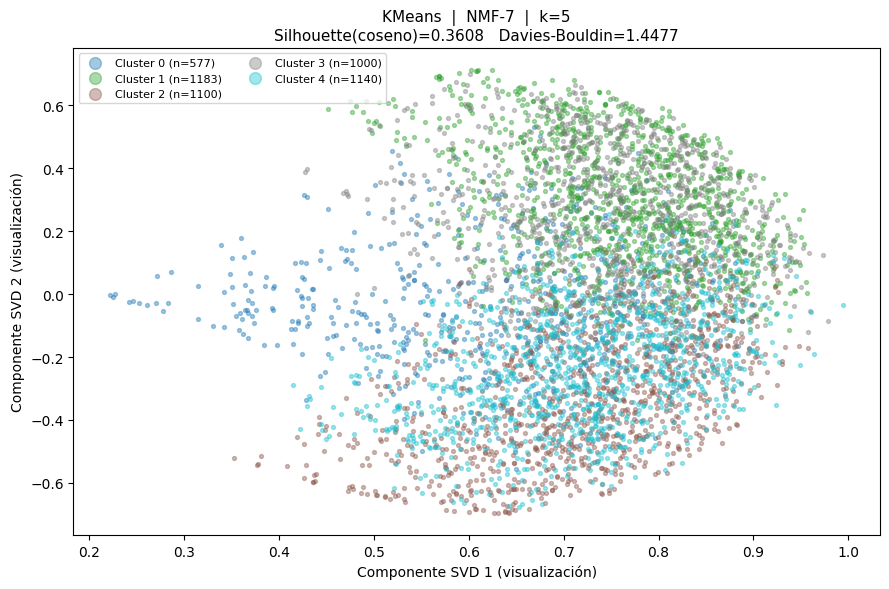

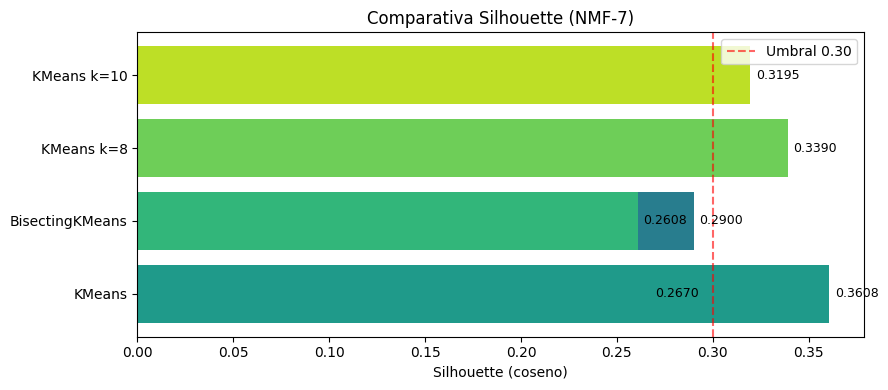

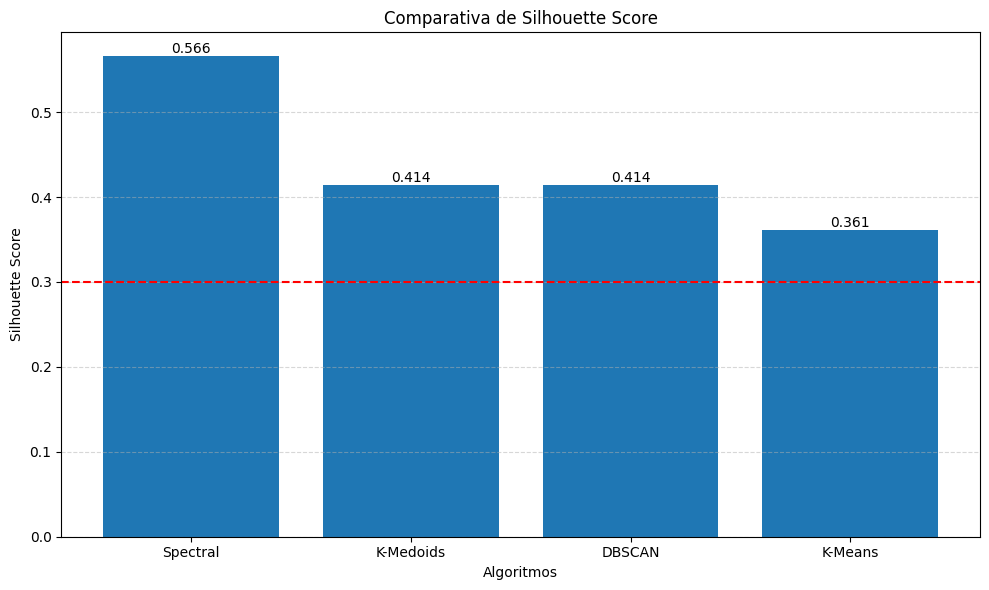

In [39]:
# =========================================================
# COMPARATIVA VISUAL DEL SILHOUETTE SCORE
# =========================================================

# Diccionario para almacenar los scores
silhouette_scores = {}

# Recuperar resultados guardados previamente
for nombre_modelo, resultados in resultados_globales.items():

    # Verificamos que exista la métrica
    if "silhouette" in resultados:
        silhouette_scores[nombre_modelo] = resultados["silhouette"]

# Verificación de seguridad
if len(silhouette_scores) == 0:
    print("No se encontraron métricas silhouette.")
else:

    # Datos para la gráfica
    modelos = list(silhouette_scores.keys())
    scores = list(silhouette_scores.values())

    # Crear gráfica
    plt.figure(figsize=(10, 6))

    bars = plt.bar(modelos, scores)

    # Mostrar valores encima de cada barra
    for bar in bars:
        altura = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            altura,
            f"{altura:.3f}",
            ha='center',
            va='bottom'
        )

    # Configuración visual
    plt.title("Comparativa de Silhouette Score")
    plt.xlabel("Algoritmos")
    plt.ylabel("Silhouette Score")
    plt.axhline(y=0.3, color='red', linestyle='--',label='Umbral aceptable (0.3)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()